# A Breeze tutorial: thermal bubbles to cloudy hills

Documentation for Breeze is available at
[numericalearth.github.io/BreezeDocumentation](https://numericalearth.github.io/BreezeDocumentation/dev/).

This tutorial introduces Breeze using four experiments:

| Part | What's new                              | Dynamics                    |
|:----:|-----------------------------------------|-----------------------------|
| I    | Dry thermal bubble                      | anelastic                   |
| II   | Forced convection over a warm surface   | anelastic                   |
| III  | Forced convection over a hill           | split-explicit compressible |
| IV   | Cloudy, hilly convection                | split-explicit compressible |

## Environment management

We begin by instantiating the environment:

In [63]:
using Pkg
Pkg.instantiate()

and then we can get onto to building the environment,

In [64]:
using Breeze
using Oceananigans: Oceananigans
using Oceananigans.Units
using Printf
using Random
using CairoMakie
using CUDA

It pays to *be careful* about which versions are actually in play. We print the
environment status *after* the `using` statements on purpose: only then will
`Pkg.status` annotate any package whose loaded version differs from the resolved
one, e.g. `Breeze v0.6.0 [loaded: v0.5.3]`. That bracketed note means a stale
version is still loaded in this session (Julia can't hot-swap a loaded package) —
if you see it, restart the kernel so the resolved version is the one in memory.

In [65]:
Pkg.status()

arch = GPU()
Oceananigans.defaults.FloatType = Float32

Status `~/ondemand/BjerknesWorkshop/tutorials/day2/Project.toml`
  [660aa2fb] Breeze v0.6.0
  [179af706] CFTime v0.2.10
  [052768ef] CUDA v6.2.0
  [13f3f980] CairoMakie v0.15.11
  [6ba0ff68] ClimaSeaIce v0.5.6
⌃ [6a9e3e04] CloudMicrophysics v0.35.0
  [cd43e856] CopernicusMarine v0.1.2
  [db073c08] GeoMakie v0.7.16
  [da04e1cc] MPI v0.20.26
  [904d977b] NumericalEarth v0.5.6 `https://github.com/NumericalEarth/NumericalEarth.jl#glw/support-breeze-0.6`
⌃ [9e8cae18] Oceananigans v0.110.1
  [d496a93d] SeawaterPolynomials v0.3.10
  [10745b16] Statistics v1.11.1
  [ade2ca70] Dates v1.11.0
  [de0858da] Printf v1.11.0
  [9a3f8284] Random v1.11.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


Float32

A small helper that base64-embeds a finished `.mp4` in an HTML5 `<video>` tag,
so the animation plays inline in the notebook (no external file serving needed).

In [66]:
using Base64

mp4_html(path) = HTML(string("<video autoplay loop muted playsinline controls ",
                             "src=\"data:video/mp4;base64,", base64encode(read(path)),
                             "\" style=\"max-width:100%\"></video>"))

mp4_html (generic function with 1 method)

## The shared grid and background atmosphere

A single vertical slice serves every part: 24 km wide, 8 km tall, periodic in
`x` and `Flat` in `y`. Two-dimensional dynamics are a cartoon — 2D turbulence
has no vortex stretching — but they are cheap enough to run in minutes and rich
enough to show everything we want to point at. WENO advection of order 9 needs a
halo of five cells. (Crank `Nx, Nz` back up for a crisper movie.)

In [67]:
Lx, Lz = 24kilometers, 8kilometers
Nx, Nz = 384, 160

grid = RectilinearGrid(arch;
                       size = (Nx, Nz),
                       halo = (5, 5),
                       x = (-Lx/2, Lx/2),
                       z = (0, Lz),
                       topology = (Periodic, Flat, Bounded))

384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── Periodic x ∈ [-12000.0, 12000.0) regularly spaced with Δx=62.5
├── Flat y                           
└── Bounded  z ∈ [0.0, 8000.0]       regularly spaced with Δz=50.0

## The anelastic approximation and the reference state

The first three parts use **anelastic** dynamics. The atmosphere is compressible,
but sound waves are energetically irrelevant to convection and would force a tiny
time step, so the anelastic approximation filters them: each field splits into a
static, horizontally-uniform **reference profile** plus a small
**perturbation** (prime),

$$
ρ = ρ_r(z) + ρ', \qquad p = \bar p(z) + p', \qquad |ρ'| \ll ρ_r ,
$$

with the reference state in hydrostatic balance, $d\bar p/dz = -ρ_r g$. Mass
conservation reads

$$
\frac{∂ρ}{∂t} + ∇·(ρ \, 𝐮) = 0 ,
$$

and dropping $∂ρ'/∂t$ — which is what removes the acoustic modes — leaves the
**anelastic constraint**

$$
∇·(ρ_r \, 𝐮) = 0 ,
$$

while $p'$ is then diagnostic, from an elliptic solve enforcing that constraint.

The reference column is fixed by a single function, the **reference potential
temperature** `\bar θ(z)`: with a surface pressure, hydrostatic balance and the
ideal-gas law then close `\bar p(z)`, `\bar T(z)`, and the background density
$ρ_r(z)$. So handing `ReferenceState` a `\bar θ(z)` is what produces $ρ_r(z)$.
We take a constant buoyancy frequency $N$. Since

$$
N^2 = \frac{g}{\bar θ} \frac{d\bar θ}{dz} ,
$$

$\bar θ$ is exponential,

$$
\bar θ(z) = θ_0 \, e^{N^2 z / g} ,
$$

anchored at `θ₀ = 290 K`. WENO order-9 advection serves all four parts.

In [68]:
θ₀ = 290     # K, surface potential temperature
N² = 1e-6    # s⁻², stratification (N = 0.001 s⁻¹)
g  = 9.81    # m s⁻², gravitational acceleration

θ̄(z) = θ₀ * exp(N² * z / g)

reference_state = ReferenceState(grid; potential_temperature = θ̄)
dynamics = AnelasticDynamics(reference_state)
advection = WENO(order = 9)

model = AtmosphereModel(grid; dynamics, advection)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: AnelasticDynamics(p₀=101325.0, θ₀=290.0)
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: SSPRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

Notice that `AtmosphereModel` solves the governing equations in **conservative
(flux) form**: the prognostic variables are the *densities* of momentum, heat, and
moisture — $ρ𝐮$, $ρθ$, $ρq^v$, $ρe$ — rather than the velocities and
potential temperature themselves. This is visible in the model's printed summary
above, where the advected quantities are listed as `ρθ` and `ρqᵛ` and the forcing
entries act on `ρu`, `ρv`, `ρw`, `ρθ`, `ρqᵛ`, and `ρe`. Diagnostics such as
`liquid_ice_potential_temperature(model)` recover the familiar primitive variables
(e.g. $θ = ρθ / ρ$) on demand.

For the full conservative-form governing equations and the details of the anelastic
approximation, see the
[anelastic dynamics](https://numericalearth.github.io/BreezeDocumentation/dev/anelastic_dynamics/)
page of the Breeze documentation.

## Part I — a dry thermal bubble

A warm perturbation `θ' = θ - \bar θ(z)` feels a buoyancy

$$
b = -g \, \frac{ρ'}{ρ_r} = g \, \frac{θ'}{\bar θ}
$$

(exact in the anelastic system, where buoyancy is evaluated at the reference
pressure so `p'` drops out): `θ' > 0` rises, which is why we plot `θ'` throughout.

The "hello, world" of atmospheric dynamics: a blob of air 10 K warmer than its
surroundings, released at rest. It is buoyant, so it rises; as it rises it rolls
up into the classic mushroom vortex pair, overshoots the height where the
stratification matches its excess warmth, and rings the surrounding atmosphere
with gravity waves. We paint the warmth onto the initial condition as a smooth
cone of radius `r₀` centered at height `z₀`.

In [69]:
Δθ = 2              # K, bubble amplitude
r₀ = 1.5kilometers  # bubble radius
z₀ = 2kilometers    # release height

θ_bubble(x, z) = θ̄(z) + Δθ * max(0, 1 - sqrt(x^2 + (z - z₀)^2) / r₀)
set!(model, θ=θ_bubble)

Let's visualize the initial condition:

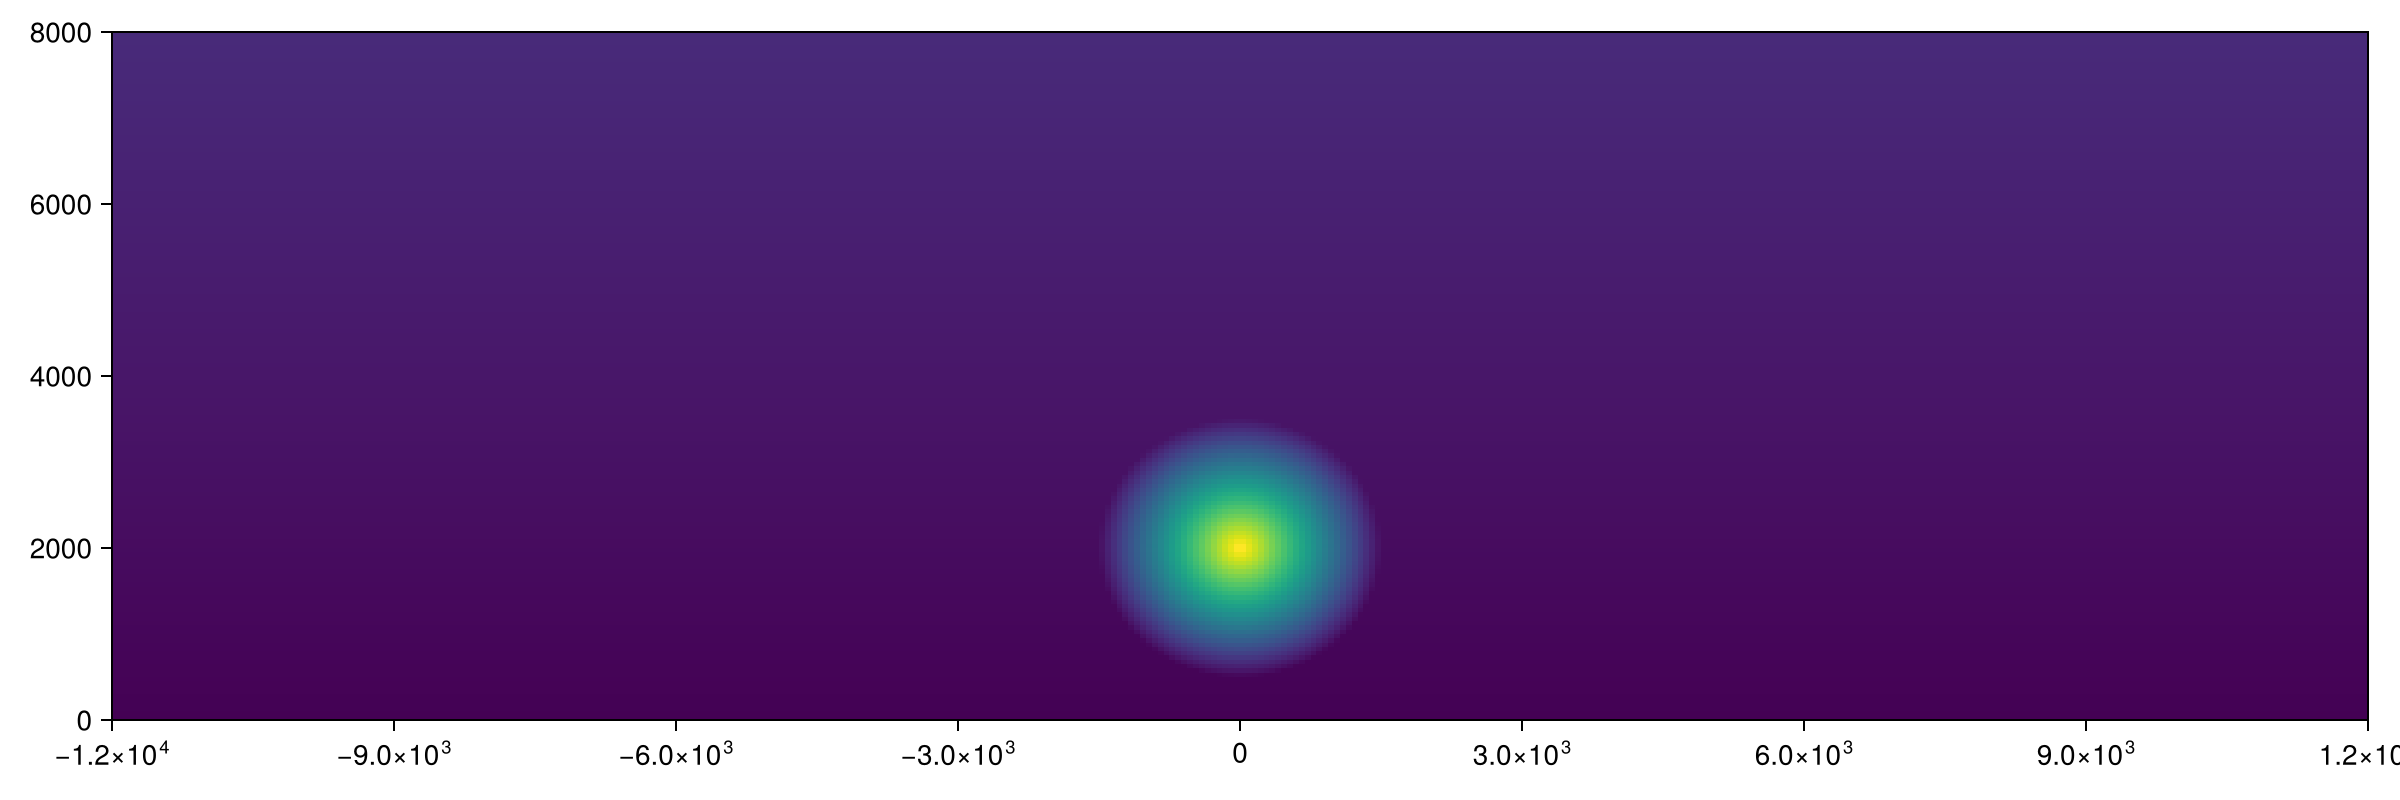

CairoMakie.Screen{IMAGE}


In [70]:
fig = Figure(size=(1200, 400), aspect=3)
ax = Axis(fig[1, 1])
heatmap!(ax, liquid_ice_potential_temperature(model))
display(fig)

A CFL wizard adapts the time step as the bubble accelerates; with Runge–Kutta
time stepping and WENO advection the conventional anelastic stability target is
`cfl = 0.7`. A progress callback logs the wall-clock march periodically.

In [71]:
simulation = Simulation(model; Δt=1, stop_time=25minutes)
conjure_time_step_wizard!(simulation, cfl=0.7)

function progress(sim)
    @info @sprintf("thermal bubble | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

We save the potential-temperature *perturbation* `θ′ = θ - θ̄(z)` — the signal
the bubble carries above the background — together with the velocities, once a
minute.

In [72]:
θ = liquid_ice_potential_temperature(model)
θ̄_field = Field{Nothing, Nothing, Center}(grid)
set!(θ̄_field, θ̄)
θ′ = θ - θ̄_field
outputs = (; θ′, model.velocities...)

bubble_ow = JLD2Writer(model, outputs;
                       filename = "thermal_bubble.jld2",
                       schedule = TimeInterval(1minute),
                       overwrite_existing = true)

simulation.output_writers[:fields] = bubble_ow

JLD2Writer scheduled on TimeInterval(1 minute):
├── filepath: thermal_bubble.jld2
├── 4 outputs: (θ′, u, v, w)
├── array_type: Array{Float32}
├── including: [:thermodynamic_constants]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

Now we are ready to run the simulation,

In [73]:
run!(simulation)

[ Info: Initializing simulation...
[ Info: thermal bubble | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 0.00e+00 m s⁻¹
[ Info:     ... simulation initialization complete (2.752 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (5.716 ms).
[ Info: thermal bubble | iter: 200, t: 8.848 minutes, Δt: 3.427 seconds, max|w|: 1.02e+01 m s⁻¹
[ Info: thermal bubble | iter: 400, t: 17 minutes, Δt: 2.124 seconds, max|w|: 1.30e+01 m s⁻¹
[ Info: thermal bubble | iter: 600, t: 24.378 minutes, Δt: 2.546 seconds, max|w|: 9.96e+00 m s⁻¹
[ Info: Simulation is stopping after running for 6.052 seconds.
[ Info: Simulation time 25 minutes equals or exceeds stop time 25 minutes.


### The movie

Replay every saved frame as a heatmap of `θ′`.
movie so it plays inline.

In [74]:
θ′_ts = FieldTimeSeries("thermal_bubble.jld2", "θ′")
Nt = length(θ′_ts)

fig = Figure(size=(1200, 400), aspect=3)
ax = Axis(fig[1, 1])

n = Observable(1)
θ′n = @lift θ′_ts[$n]
heatmap!(ax, θ′n)

CairoMakie.record(fig, "thermal_bubble.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("thermal_bubble.mp4")

[ Info: Drawing frame 1 of 26...
[ Info: Drawing frame 2 of 26...
[ Info: Drawing frame 3 of 26...
[ Info: Drawing frame 4 of 26...
[ Info: Drawing frame 5 of 26...
[ Info: Drawing frame 6 of 26...
[ Info: Drawing frame 7 of 26...
[ Info: Drawing frame 8 of 26...
[ Info: Drawing frame 9 of 26...
[ Info: Drawing frame 10 of 26...
[ Info: Drawing frame 11 of 26...
[ Info: Drawing frame 12 of 26...
[ Info: Drawing frame 13 of 26...
[ Info: Drawing frame 14 of 26...
[ Info: Drawing frame 15 of 26...
[ Info: Drawing frame 16 of 26...
[ Info: Drawing frame 17 of 26...
[ Info: Drawing frame 18 of 26...
[ Info: Drawing frame 19 of 26...
[ Info: Drawing frame 20 of 26...
[ Info: Drawing frame 21 of 26...
[ Info: Drawing frame 22 of 26...
[ Info: Drawing frame 23 of 26...
[ Info: Drawing frame 24 of 26...
[ Info: Drawing frame 25 of 26...
[ Info: Drawing frame 26 of 26...


HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQABad1tZGF0AAACsAYF//+s3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz0yNCBsb29rYWhlYWRfdGhyZWFkcz00IHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49MjQgc2NlbmVjdXQ9NDAgaW50cmFfcmVmcmVzaD0wIHJjX2xvb2thaGVhZD01MCByYz1jcmYgbWJ0cmVlPTEgY3JmPTI4LjAgcWNvbXA9MC42MCBxcG1pbj0wIHFwbWF4PTY5IHFwc3RlcD00IGlwX3JhdGlvPTEuNDAgYXE9MToxLjAwAIAAACPQZYiEADv//vWxfApqyfMxm4aowkYr8KnXsXwE/x8AAAMAAAMAAAMAAAMAAAMAEVurwONH4gXJXU0+ic1kO/fmoZ77upIv14LZellhhJMeDHcEJjgZ8CL9UBpG9CBjrCVxyTX8KMs79yPvPi+Xyd7mlrKacVaA6MUlLtEOaD6neCDJmYPXVlPgPiNq/C0Q2pMyeoYRXuD0eCWLYI0NrKVR5kLDKM+snqlYydB/QSEGd6cIggD1RIGQHgKsFqqzlhuwpG7M1IIiAs92HyJu3VGq6TyudPEqO7RfQa+WpcJ39dzHGYYvXsXpy9B5G4SzcwwnVfMKz+8YpZvGTn48hBbm7LoTPxyGo+oQX9ESo1jEfrugw3+3zeHPseoH7s+Fn1Y1hoGQowDIgnYAO0QRMhnkhGBFQtoY+pVK4zwYnOJoQXyJWH1bBh/Kli6j1KmNZgIq2fLqMvl4toAAAAMAABLpXKdYUoDZYehihvcPdIsopRKizTkYpHdpSyDtlurgFWVQxaMH/7A+5kIyrmaLpJ/da1ovtDRJyQO/400xhiM3ITufdARvlNaCnCC+2C/Y0Mx//A7XQ5ZMiAidVecsVofAb3L8ogbbOWCOr3rdN4RjNLllEmQibq/sH+F07t7GfGrXNXWlYraOqbzp/m/KqYg9xLdGL5eqfnUjbqHtx81LwaDm1Qa+70vDKOue9I0tJL3iWYyuE/Kh/JUL2cfquK0TEfAt1XMZFkI4fr+zpPLQRRxUWswkrMegF3DSq4wZ5VzlclYZkJKCJXgqiSDWc3j3csNiQrycY8hmPGTtKvIYS2VCQInj5SuAt1ZBSwwigqIBi001QDgrFishw0RZw44S+ULd8dxLs/r6jZyz3GDJz7gxSvHdWOAAAAMAAAMAAEatHr77p5uQlenfAlVAIPTD9xc9qwBzxMXsrDq6dILNurfHp+D1kOBYUp5RwAAAAwAAAwBfiVZWJPLDRIt4AAADAAAKS0oFw4AAAAMAR0JHCqAAAAMBd1y8dAAAAwA2NMAgAAADABa6+cQAAAMAFliklAAAAwAm9YCAAAADAFvHqOY65Hw0natTa+QEhq0pM9IMBdJIMPh6k84Yuuw+2cxxhy3hXTxf/dLz7HA85tTitfQGb7BTBmwKEf7wqwlXDMyjDB7s5xwtQYWpbuC40AcjGEWnoFksW6mmqM2WvIvXsrbyvTmSuYJEHed04D500B9UETKNwhr8jAuaW0aAFbZ/q3ET2g8BV2D6Ggh3eG/qbRn8OYfxqwajxBWw8Wki5M4gIrXPLa5w3hPbTBEAHR5pOt/S5x4EOMXvxvt/cDOX7Q+9GPqdcfPgFFndAGx7RhZhBrd0YG5j88swNZxmLds60spcGFK+XdI3YoEeF36U8F+IJ+jCd0OB10+DVJ6iXHlnxXuZfn+oBQ2i8g2RywosKOVGNDLQCbcb0qVgkE+Ny/cpw2Z1M1V/4U9MDchyFJ/dpyP5GU/UhoR4qPL9FwO1Tn8200RawifjHRlNQX4Ha+fLLZtPvTtV8zRO9gAAAwAALdOZ77ePKqnlfQNkKt7jGdmNuL5A5hgBKEhOvht9cbxNm0m4WYsUium5R+kDij+CyL4RDufuPOd9gwlwpj05DSCACbQs9F9wwN7LlW1yJu6Lv2vBOMAJmVZXAUV1ltdWgQtRnm1lZm5YcHSvkRWXWUkxYKh9MZX4uHZ73sUdRt7mOTEey3ArgMZHQLwy7UcNF6o7sqIxjrwEZHinRZp1kBkh2snyhZ7VeYMFsi8xtLMB3YXLVMXPmR5H0TbKJjJuvdEmMyNNn+BelgAAAwAAHzaAwLzewAAAAwJO7uK0AAADACTr++gAAAMASeG1gAAAAwC2cr6AAAADAtnUegAAAwALZ4dgAAADAC2eq8AAAAMBJ/Fu7wfkgzRv1Dx2NjnRgsbj2rpGQjmKKgzVfWQ6+Zqvq8LMSjgp+PFVfUIfnXMINnFB57Q1z9bDU6qdxlUPziXYZwd3E5U48ymHouj+iuURoEuk/q1EbEFJbOAAAAMABWuEPQ8ldkchqR68rJTBwonKnrEDeYB1vzwtncjaMUjyv7pZRxFOZJaHsmgvhvC01GzTLpijF15rqVdlKrsf1uZhoTob2VPXWVnOWdnpouRpPCTpTu5KkAzpEIQb8fW7nfJEz7mUEnL/jMINw9WCBwi/FpAEFzbJ+Ip0HMjjV1RqjxHEVhIJLS6oatB1RvA0yegTo7iuhmeGMnFvfz0648WPYuFg1E4P+g0+1eIi0081Bnnma1F/oAzPtmXPKmcYY3GL0U+o+ftTRestvph8VylV3ViaL8s41uYoB0xn+pEy0GsrYlLv3yzx5vErn2t1/Hj2sEg5lYKEWXEFq6ItuYemssxKAXfrnYr906U6Ccw1SxsTGQ/Kg7u4LQXfhLtfAjGoyPIQJw9/NXuqTdphDuLTa9Zy4fRqsOWc+yeOno6TWcpZU+Bt55UEAy1DXLSIGEYbbzyRzrRiE1g4BphL3iAAAAMAAtFANmNzXPTcnS7fO9YIbiBGhHvoXubemaQm3pOijsOGUJYi57TK7UMnZWndAKHbYTvQG+KfvwgmXE7YvZN77X9u0ALWa8yEf22/YcfozQNkRLwQlj0fjJ5LwunmQ9Ri0eShAHgAAAMAALRRRygAAAMALRY0UAHSe64ujCnPnLuZQ38jm7K2X8QWn9Gl+P5xc97VAAADAAATBeGpdkyAAAIb4Yv/9INK/dUxZKMLhyyVVdWyUXBYHwO5svlQEcWtmHl5PPFohq98doqJlO+eymkM5AhxZcAAAAMABf2oxudIAAAHz82KK/+nqNEJDbrn/3N0OrjfkP02mDz1zmkhy6NCm6nECGCCC5AdZtembi68dSDsaAHQAAAbJKwJ9X8cAAADAE+9+7F/73zCEwb75kxKltCAIh

## Part II — free convection off a warm surface

Same grid, same anelastic dynamics — but now the warmth comes through the
*boundary* instead of being painted on the initial condition. Breeze computes
the turbulent surface exchange with bulk aerodynamic formulae: a sensible heat
flux and a vapor flux out of a sea held at `θ₀`, plus a drag on the wind. The
`coefficient` sets the exchange strength; feeding the instantaneous LES wind
into a quadratic bulk formula would alias resolved turbulence into the mean
flux, so a `gustiness` floor keeps the exchange finite in calm spots.

In [75]:
coefficient = 2e-3
gustiness = 1e-1
surface_temperature = θ₀ + 10
q_bottom_bc = BulkVaporFlux(; coefficient, gustiness, surface_temperature)
θ_bottom_bc = BulkSensibleHeatFlux(; coefficient, gustiness, surface_temperature)
u_bottom_bc = BulkDrag(; coefficient, gustiness)

ρq_bcs = FieldBoundaryConditions(bottom=q_bottom_bc)
ρθ_bcs = FieldBoundaryConditions(bottom=θ_bottom_bc)
ρu_bcs = FieldBoundaryConditions(bottom=u_bottom_bc)

boundary_conditions = (; ρq=ρq_bcs, ρθ=ρθ_bcs, ρu=ρu_bcs)
model = AtmosphereModel(grid; dynamics, advection, boundary_conditions)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: AnelasticDynamics(p₀=101325.0, θ₀=290.0)
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: SSPRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

The lowest layer warms, goes unstable, and organizes into thermals that punch
upward and erode the stratification from below, growing a convective boundary
layer. We start from the background profile plus a whisper of noise and a light
mean wind (`u = 5 m s⁻¹`) to lean the plumes and work the bulk formulae.

In [76]:
θᵢ(x, z) = θ̄(z) + 1e-2 * randn()
set!(model, θ=θᵢ, u=5)

simulation = Simulation(model; Δt=1, stop_time=2hours)
conjure_time_step_wizard!(simulation, cfl=0.7)

function progress(sim)
    @info @sprintf("free convection | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θ̄_field
outputs = (; θ′, model.velocities...)

convection_ow = JLD2Writer(model, outputs;
                           filename = "free_convection.jld2",
                           schedule = TimeInterval(1minute),
                           overwrite_existing = true)

simulation.output_writers[:fields] = convection_ow

JLD2Writer scheduled on TimeInterval(1 minute):
├── filepath: free_convection.jld2
├── 4 outputs: (θ′, u, v, w)
├── array_type: Array{Float32}
├── including: [:thermodynamic_constants]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

and then we run the simulation,

In [77]:
run!(simulation)

[ Info: Initializing simulation...
[ Info: free convection | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 0.00e+00 m s⁻¹
[ Info:     ... simulation initialization complete (3.346 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (7.004 ms).
[ Info: free convection | iter: 200, t: 10.112 minutes, Δt: 7.400 seconds, max|w|: 2.99e-01 m s⁻¹
[ Info: free convection | iter: 400, t: 26.627 minutes, Δt: 3.715 seconds, max|w|: 4.05e+00 m s⁻¹
[ Info: free convection | iter: 600, t: 38.376 minutes, Δt: 3.833 seconds, max|w|: 3.50e+00 m s⁻¹
[ Info: free convection | iter: 800, t: 50.062 minutes, Δt: 3.695 seconds, max|w|: 4.53e+00 m s⁻¹
[ Info: free convection | iter: 1000, t: 1.022 hours, Δt: 3.355 seconds, max|w|: 5.48e+00 m s⁻¹
[ Info: free convection | iter: 1200, t: 1.197 hours, Δt: 3.350 seconds, max|w|: 5.26e+00 m s⁻¹
[ Info: free convection | iter: 1400, t: 1.372 hours, Δt: 3.273 seconds, max|w|: 4.95e+00 m s⁻¹
[ Info: free convection | iter: 1

### The movie

We plot two fields side by side: the potential-temperature perturbation `θ′` and the
vertical velocity `w`. Both are signed, so both use the diverging `:balance` colormap
over a symmetric, frame-fixed range. The `w` panel makes the convective structure
explicit — narrow, vigorous updrafts punching up between broader, gentler downdrafts —
which is exactly what we will contrast against the terrain-forced flow in Part III.

In [78]:
θ′_ts = FieldTimeSeries("free_convection.jld2", "θ′")
w_ts  = FieldTimeSeries("free_convection.jld2", "w")
Nt = length(θ′_ts)
θ′max = maximum(abs, θ′_ts[Nt])
wmax  = maximum(abs, w_ts)

fig = Figure(size=(1200, 700))
axθ = Axis(fig[1, 1], title="potential temperature perturbation θ′ (K)")
axw = Axis(fig[2, 1], title="vertical velocity w (m s⁻¹)")

n = Observable(1)
θ′n = @lift θ′_ts[$n]
wn  = @lift w_ts[$n]
hmθ = heatmap!(axθ, θ′n, colormap = :balance, colorrange = (-θ′max, θ′max))
hmw = heatmap!(axw, wn,  colormap = :balance, colorrange = (-wmax, wmax))
Colorbar(fig[1, 2], hmθ)
Colorbar(fig[2, 2], hmw)

CairoMakie.record(fig, "free_convection.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("free_convection.mp4")

[ Info: Drawing frame 1 of 121...
[ Info: Drawing frame 2 of 121...
[ Info: Drawing frame 3 of 121...
[ Info: Drawing frame 4 of 121...
[ Info: Drawing frame 5 of 121...
[ Info: Drawing frame 6 of 121...
[ Info: Drawing frame 7 of 121...
[ Info: Drawing frame 8 of 121...
[ Info: Drawing frame 9 of 121...
[ Info: Drawing frame 10 of 121...
[ Info: Drawing frame 11 of 121...
[ Info: Drawing frame 12 of 121...
[ Info: Drawing frame 13 of 121...
[ Info: Drawing frame 14 of 121...
[ Info: Drawing frame 15 of 121...
[ Info: Drawing frame 16 of 121...
[ Info: Drawing frame 17 of 121...
[ Info: Drawing frame 18 of 121...
[ Info: Drawing frame 19 of 121...
[ Info: Drawing frame 20 of 121...
[ Info: Drawing frame 21 of 121...
[ Info: Drawing frame 22 of 121...
[ Info: Drawing frame 23 of 121...
[ Info: Drawing frame 24 of 121...
[ Info: Drawing frame 25 of 121...
[ Info: Drawing frame 26 of 121...
[ Info: Drawing frame 27 of 121...
[ Info: Drawing frame 28 of 121...
[ Info: Drawing frame 29 of 1

HTML{String}("<video autoplay loop muted playsinline controls src=\"data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQARfNdtZGF0AAACsAYF//+s3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzIwM00gNTJmNzY5NCAtIEguMjY0L01QRUctNCBBVkMgY29kZWMgLSBDb3B5bGVmdCAyMDAzLTIwMjQgLSBodHRwOi8vd3d3LnZpZGVvbGFuLm9yZy94MjY0Lmh0bWwgLSBvcHRpb25zOiBjYWJhYz0xIHJlZj01IGRlYmxvY2s9MTowOjAgYW5hbHlzZT0weDM6MHgxMTMgbWU9aGV4IHN1Ym1lPTggcHN5PTEgcHN5X3JkPTEuMDA6MC4wMCBtaXhlZF9yZWY9MSBtZV9yYW5nZT0xNiBjaHJvbWFfbWU9MSB0cmVsbGlzPTIgOHg4ZGN0PTEgY3FtPTAgZGVhZHpvbmU9MjEsMTEgZmFzdF9wc2tpcD0xIGNocm9tYV9xcF9vZmZzZXQ9LTIgdGhyZWFkcz0yNCBsb29rYWhlYWRfdGhyZWFkcz00IHNsaWNlZF90aHJlYWRzPTAgbnI9MCBkZWNpbWF0ZT0xIGludGVybGFjZWQ9MCBibHVyYXlfY29tcGF0PTAgY29uc3RyYWluZWRfaW50cmE9MCBiZnJhbWVzPTMgYl9weXJhbWlkPTIgYl9hZGFwdD0xIGJfYmlhcz0wIGRpcmVjdD0zIHdlaWdodGI9MSBvcGVuX2dvcD0wIHdlaWdodHA9MiBrZXlpbnQ9MjUwIGtleWludF9taW49MjQgc2NlbmVjdXQ9NDAgaW50cmFfcmVmcmVzaD0wIHJjX2xvb2thaGVhZD01MCByYz1jcmYgbWJ0cmVlPTEgY3JmPTI4LjAgcWNvbXA9MC42MCBxcG1pbj0wIHFwbWF4PTY5IHFwc3RlcD00IGlwX3JhdGlvPTEuNDAgYXE9MToxLjAwAIAAAHClZYiEADv//vWxfApqyfMxm4aowkYr8KnXsXwE/x8AAAMAAAMAAAMAAAMAAAMAEVlZ0ntn6IY+DgAAAwAAAwAAAwDRAD+g4HGj8QDS69xUEimmXuoZbjEZCFYQAdfFAu8fdMrgRsqVAtBoBuOCAGkVj5aFBGfUWDy2mOXdbdPaRPS7EGBdpQkIK9i9BBHL4YGBPYNjB2rDlX1+fXvw41YNJ1eB/ZNUWfbF9R4PPcoJ/mtK1HPLegoHN2U9jMOL9+B+HHzP7HpQ2DzuYTkrMliEj+CbR02Huj+lOvDksnuwhD6PBK58uTQVqEXQ54GKh3BnuynRb2Kaj/WpsPfKTv89iZrCvroUsPU8o7j/jeVN1HKxsPHa7suE2B8aOafw415N/5wTbFM74Jk0WGSFQjT/9QSUYhOoof6UTpMqTBL7w7ZCt/VNAGoHvopyKNV1ZIdsGiETTKHB9+mpseJA41RzbDiCs6GIB2lZRdl3NkrIAR734LkPJtnkUYno89bI4f+xgO9gMpkN7jkp85VPD9vn6igjLwMVjvaAoTIX8tpU21JGKc5cOr/hU50KvaLbN0iES/fj1OhNEfvGUMKp5i4px6Pl81WZuXNGaWXP6b+DIrvqTlTsoAAoOID1nAvwl7oJK4gbaWfg6SgQ0SHktDrCDHhspW/If6oXi/H3he2npU9xKzZWOa2NBUwYA+gBefKUP3mSO8hyBD3tBv/NVW4nAHBu4AtsXh1F35RLOhMZUCrD3+/JJRRwuJOAn543IgHmWQUhynhvqoFWl+S/r1oHjUeZNlWnHyDnYueoK8GKxv2/onZiiD1liBTps7q4VVvBVHAw3u92+5UEmQmM2/1MZFZz+Ye/FP+/FeGF9mPqvdsZFZIe87DcVPh3g8xYR8WPqQCnY/Tw8eB7em7K6fgFgSjXMGMY3tcTAB9Y3rcxJ1PbD98Xxsg9R0hmEvb3nC93sJILhKjUNRyuWk/COg5ZylXt29DAVEyfPvSYCGRwSAfRDmZ6ZSV3cYz5WVUn5OHkU4HbBECX5dhBUhxYjFh92TRQqZvGqhYFlWPSgfM77hs1ffjYpexPmtdrZPZykG661eepZPz1PpEJwW926jITPXEF8t3jG1XI2+F6/PyHKBjIOD+D/3SsMf469iVTbhteMHlFWANquOr3MZiHB1K7pEipgXDP5rMayiMpb47b5y398eBLh9J3puiTVYcTo3tUQcq9HciFmWdmIx0kuxuahfz+P1YWHqkWR8APbENuzFPDenm+O06AmqwawNZ5g+2CRvDMoBUgGTVSt9LRBTKqjDE3MYiPzbqfsD8KBkQsZpcV1jkrNfYaDTId8R1x8tSQWjwaahqCyS5u78gk3OpszIVGLKbIA+BGi5nkfGZmQhq3Rxj7FJb3hsPC806RBQB1Fvk8AAUVn4W2SgfFFHrakAhdOJM+/ulDTuBrJNKxRqD33nL6bC25JakVJZ6Ln2B0+adKrDkvBP1sRsWu3p3XEoRTPggIAtX8N3HiXwckPDaclsR+BhkBkPO1gXgaWTjpct9ldEEHIgMKsq8S02ryKj4ZIc24XaZjGD+irAikfbKN+YlcYe+iyKILK7j23buSuzKNHP8SGD0V3Vyq5a5KwKX28f6LQF8GknygiSnHVp23Vd/duA4FpEfqJi820oOBc59w787akTPjLcKlQ5x4gPLd2MQVNAN9MMyW5Mv/arNxfXzPQ6LmtLLBUKL5VscBOTsACkDPRpiU/weLyw6nplEDw6giwFH8ghXTMCoICkqQYTCFXYxLe60x4t6AurfsHNxxDvdO9+P+fywzto0bA//J9TnLxKWD7uAAbbrhQAKP0rPw3i8dC1CaiCR76VAsqMnP8nhdIbXM/9DoNDDl6DQ4VmrGgzOH7lBEnGPCcpyZ6TTTUf/akmfH/Mht9kenrL+vxUQhZrlqNeT/wd27Dg0bmxOHvdwe/AB7nBcxQng5jYTamYa2PPCiBAN39Qavcg3qCsIDVD5TsFutINkzcyX6jDe6mKgkdQdJSCtANttAFcgTofKhUbAeYmuxCXtmjs6sRSJZHedEiWouksY8NuqDxF/9Wt3HXAo1eAdL5Z48mIX0KWeKi31fiYhevaInZ8a0RMME+5ATmynkIdDPtfyQrwSF1njfmZgaEDTBDr5woT+t1ukgQm0ExOR2rF6htY7MZGonrowAMV+/kHrGKxK2PuvI7fNsZ62ZHVoc9xFQnRLzANBnGFqxn0U43ANPgxe8QJMtCQ1CPkAisSO7NIiGYeV7nC1bbsu7JYrmO2zI0VktHq7PoTsraPW8PowTHlu6qW6DcxnfULVGbBxQRxGyDWuruN/wrZMUyuSEsj7IluvTN58LJaQ+7PwjbsGAYlwraG+X74zKy1qa3gRkqN6lkmYSd2B+Bxu+WVMwr4viyF9jsXGwZ9DzVkMejSVRtnmWqZ25Zc+/NsSAne7v+/XFH/jRDBtk4sWPqdGImTOuarj0B9gHvYUxeGF15nUOpBIxj4rkQt+moeuDNKDFWVrvdA7RDQm8zKXocgd3pczXYSjzK+w+8jrBRvjkJr6+J+vm884+XHyQ1omMCF6BsauY9RZq8ucczsUTpbG7pX77ux4J5m87bvIGimO2W37e0V66qauVauqrDmcjh09xKFNgm46ODXFMXMa7SvE+5ozd2LZrtJAek898404vICmo5xZQuV7cRJgj4FjzaVe39yAf/L07rXkp9Ind87LCSIwYDihP4VXhxoIF9Pvr3/z8XonJkutoICOMA9yBdOuKkOliy/GCluQSmvF2ONlbcAFkwPusd6u98uaQ41yfWLj2PRmBXOABKh6J1QfBl/B5g8aQVPhYEyUCceiIdpzxRZjT8w2ZfwBnXqvc1aLwsnKbPk6LarpTR50+/x05vgNtMMU7/VoKT6UzQYiRT5

## Part III — the same convection, now over a hill

Next we illustrate how to simulate flows over terrain using **terrain-following
coordinates**, which warp the grid so that it conforms to the underlying topography.
This warping renders the box-grid anelastic pressure solver invalid: we would either
need a new anelastic solver built for the warped geometry, or we have to solve the
equations a different way. We take the latter route and switch to a **fully
compressible** formulation, which substeps the fast acoustic dynamics to accelerate
the solve. So we put a hill in the way — the Witch of Agnesi,

$$
h(x) = \frac{h_0}{1 + x^2 / a^2} ,
$$

the classic bell of mountain-wave theory. The grid's vertical coordinate follows
the terrain near the ground and decays back to flat aloft (`TwoLevelDecay`).

In [79]:
h₀ = 1000          # m, hill height
a = 5kilometers   # hill half-width (a gentle slope keeps the flow stable)

agnesi_hill(x) = h₀ / (1 + (x / a)^2)

r = collect(range(0, Lz, length = Nz + 1))
level_formulation = TwoLevelDecay(large_scale_height = Lz / 2,
                                  small_scale_height = Lz / 8)

z = TerrainFollowingVerticalDiscretization(r, formulation=level_formulation)

agnesi_grid = RectilinearGrid(arch; z,
                              size = (Nx, Nz),
                              halo = (5, 5),
                              x = (-Lx/2, Lx/2),
                              topology = (Periodic, Flat, Bounded))

materialize_terrain!(agnesi_grid, agnesi_hill)

384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── Periodic x ∈ [-12000.0, 12000.0) regularly spaced with Δx=62.5
├── Flat y                           
└── Bounded  z ∈ [0.0, 8000.0]       variably spaced with terrain-following min(Δr)=50.0, max(Δr)=50.0

A sponge in the top 2.5 km absorbs the waves before they reflect off the model
lid back into the physics. The split-explicit discretization integrates the fast
acoustic and buoyancy terms with cheap small substeps (`acoustic_cfl = 0.5` sets
the substep from the sound speed) while advection takes the long outer step; it
stays stable up to an advective Courant number of one, so the wizard targets
`cfl = 1`. A compressible model carries density as a prognostic field, so we
initialize it from the terrain-following hydrostatic reference. The warm surface
and bulk fluxes are reused verbatim from Part II; a light mean wind of `u = 2
m s⁻¹` drifts the convection over the hill.

In [80]:
sponge = UpperSponge(damping_rate = 0.1, depth = 2.5kilometers)
split_explicit_discretization = SplitExplicitTimeDiscretization(acoustic_cfl=0.5; sponge)

dynamics = CompressibleDynamics(split_explicit_discretization;
                                reference_potential_temperature = θ̄)

model = AtmosphereModel(agnesi_grid; dynamics, advection, boundary_conditions)

AtmosphereModel{GPU, RectilinearGrid}(time = 0 seconds, iteration = 0)
├── grid: 384×1×160 RectilinearGrid{Float32, Periodic, Flat, Bounded} on CUDAGPU with 5×0×5 halo
├── dynamics: CompressibleDynamics{SplitExplicitTimeDiscretization}
├── formulation: LiquidIcePotentialTemperatureFormulation
├── thermodynamic_constants: ThermodynamicConstants{Float32}
├── timestepper: AcousticRungeKutta3
├── advection scheme: 
│   ├── momentum: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   ├── ρθ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
│   └── ρqᵛ: WENO{5, Float32, Oceananigans.Utils.BackendOptimizedDivision}(order=9)
├── forcing: @NamedTuple{ρ::Returns{Float32}, ρu::Returns{Float32}, ρv::Returns{Float32}, ρw::Returns{Float32}, ρθ::Returns{Float32}, ρqᵛ::Returns{Float32}, ρe::Returns{Float32}}
├── tracers: ()
├── coriolis: Nothing
└── microphysics: Nothing

The printed summary now reports `dynamics: CompressibleDynamics` on the
terrain-following grid, while the prognostic variables stay in conservative form
(`ρu`, `ρθ`, …) just as in the anelastic parts. With the model built, we initialize
the compressible state from the terrain-following hydrostatic reference density, add
a light wind, and run the simulation in the next block.

In [ ]:
θᵢ(x, z) = θ̄(z) + 1e-2 * randn()
ρᵢ = model.dynamics.terrain_reference_density

set!(model, ρ=ρᵢ, θ=θᵢ, u=2)

simulation = Simulation(model; Δt=1, stop_time=2hour)
conjure_time_step_wizard!(simulation, cfl=1)

function progress(sim)
    @info @sprintf("hilly free convection | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θ̄_field
outputs = (; θ′, model.velocities...)

hilly_ow = JLD2Writer(model, outputs;
                      filename = "hilly_free_convection.jld2",
                      schedule = TimeInterval(1minute),
                      overwrite_existing = true)

simulation.output_writers[:fields] = hilly_ow

run!(simulation)

[ Info: Initializing simulation...
[ Info: hilly free convection | iter: 0, t: 0 seconds, Δt: 1.100 seconds, max|w|: 2.60e-01 m s⁻¹
[ Info:     ... simulation initialization complete (253.426 ms)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (56.190 ms).


### The movie

The same two-panel layout as Part II — `θ′` above, `w` below, both `:balance` over a
fixed symmetric range. Compare the `w` panel here against the flat case: the terrain
organizes the vertical velocity, anchoring ascent over the hill rather than letting
the plumes wander freely.

In [ ]:
θ′_ts = FieldTimeSeries("hilly_free_convection.jld2", "θ′")
w_ts  = FieldTimeSeries("hilly_free_convection.jld2", "w")
Nt = length(θ′_ts)
θ′max = maximum(abs, θ′_ts[Nt])
wmax  = maximum(abs, w_ts)

fig = Figure(size=(1200, 700))
axθ = Axis(fig[1, 1], title="potential temperature perturbation θ′ (K)")
axw = Axis(fig[2, 1], title="vertical velocity w (m s⁻¹)")

n = Observable(1)
θ′n = @lift θ′_ts[$n]
wn  = @lift w_ts[$n]
hmθ = heatmap!(axθ, θ′n, colormap = :balance, colorrange = (-θ′max, θ′max))
hmw = heatmap!(axw, wn,  colormap = :balance, colorrange = (-wmax, wmax))
Colorbar(fig[1, 2], hmθ)
Colorbar(fig[2, 2], hmw)

CairoMakie.record(fig, "hilly_free_convection.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("hilly_free_convection.mp4")

## Part IV — cloud microphysics on the hilly flow

The same hilly, terrain-following, compressible setup as Part III — same grid,
same dynamics, same surface fluxes — now handed a one-moment warm-rain bulk
scheme from [CloudMicrophysics.jl](https://clima.github.io/CloudMicrophysics.jl/dev/).
Loading that package activates Breeze's bridge extension. Cloud water forms by
warm-phase **saturation adjustment**, and where it exceeds the autoconversion
threshold the clouds rain.

In [ ]:
using CloudMicrophysics

BreezeCloudMicrophysicsExt = Base.get_extension(Breeze, :BreezeCloudMicrophysicsExt)
using .BreezeCloudMicrophysicsExt: OneMomentCloudMicrophysics

cloud_formation = SaturationAdjustment(equilibrium=WarmPhaseEquilibrium())
microphysics = OneMomentCloudMicrophysics(; cloud_formation)

model = AtmosphereModel(agnesi_grid; microphysics, dynamics, advection, boundary_conditions)

θᵢ(x, z) = θ̄(z) + 1e-2 * randn()
ρᵢ = model.dynamics.terrain_reference_density

A humid initial state primes the flow for condensation: we set the relative humidity
to 90% (`ℋ = 0.9`), which Breeze converts to a vapor mixing ratio `qᵗ = ℋ qᵛ⁺` from
the local saturation value `qᵛ⁺`. Orographic lifting over the hill, plus the surface
vapor flux, then nudge parcels past saturation — cloud liquid forms, and rains once
it exceeds the autoconversion threshold. We also raise the wind to `u = 10 m s⁻¹` so
the flow climbs the hill vigorously.

In [ ]:
set!(model, ρ=ρᵢ, θ=θᵢ, u=10, ℋ=0.9)

simulation = Simulation(model; Δt=1, stop_time=1hour)
conjure_time_step_wizard!(simulation, cfl=1)

`qᶜˡ` is the specific cloud-liquid mixing ratio and `qʳ` the specific rain mixing
ratio, read straight off the model's microphysical fields.

In [ ]:
qᶜˡ = model.microphysical_fields.qᶜˡ
qʳ  = model.microphysical_fields.qʳ

function progress(sim)
    @info @sprintf("hilly cloud physics | iter: %d, t: %s, Δt: %s, max|w|: %.2e m s⁻¹, max qᶜˡ: %.2e, max qʳ: %.2e",
                   iteration(sim), prettytime(sim), prettytime(sim.Δt),
                   maximum(abs, sim.model.velocities.w), maximum(qᶜˡ), maximum(qʳ))
    return nothing
end

add_callback!(simulation, progress, IterationInterval(200))

θ = liquid_ice_potential_temperature(model)
θ′ = θ - θ̄_field
outputs = (; θ′, model.velocities..., qᶜˡ, qʳ)

cloudy_ow = JLD2Writer(model, outputs;
                       filename = "hilly_cloud_physics.jld2",
                       schedule = TimeInterval(1minute),
                       overwrite_existing = true)

simulation.output_writers[:fields] = cloudy_ow

run!(simulation)

### The movie

Now there is something to *see*: the vertical velocity `w` lifting air over the hill,
the cloud liquid `qᶜˡ` that condenses where parcels pass saturation, and the rain
`qʳ` that falls out below. Clouds use the sequential `:dense` colormap and rain the
`:amp` colormap, each over a fixed range; `w` keeps the diverging `:balance` map.

In [ ]:
w_ts   = FieldTimeSeries("hilly_cloud_physics.jld2", "w")
qᶜˡ_ts = FieldTimeSeries("hilly_cloud_physics.jld2", "qᶜˡ")
qʳ_ts  = FieldTimeSeries("hilly_cloud_physics.jld2", "qʳ")
Nt = length(w_ts)

wmax   = maximum(abs, w_ts)
qᶜˡmax = max(1e-6, maximum(qᶜˡ_ts))
qʳmax  = max(1e-6, maximum(qʳ_ts))

fig = Figure(size=(1000, 900))
axw = Axis(fig[1, 1], title="vertical velocity w (m s⁻¹)")
axc = Axis(fig[2, 1], title="cloud liquid qᶜˡ (kg kg⁻¹)")
axr = Axis(fig[3, 1], title="rain qʳ (kg kg⁻¹)")

n = Observable(1)
wn   = @lift w_ts[$n]
qᶜˡn = @lift qᶜˡ_ts[$n]
qʳn  = @lift qʳ_ts[$n]

hmw = heatmap!(axw, wn,   colormap = :balance, colorrange = (-wmax, wmax))
hmc = heatmap!(axc, qᶜˡn, colormap = :dense,   colorrange = (0, qᶜˡmax))
hmr = heatmap!(axr, qʳn,  colormap = :amp,     colorrange = (0, qʳmax))

Colorbar(fig[1, 2], hmw)
Colorbar(fig[2, 2], hmc)
Colorbar(fig[3, 2], hmr)

CairoMakie.record(fig, "hilly_cloud_physics.mp4", 1:Nt; framerate = 24, compression = 28) do nn
    @info "Drawing frame $nn of $Nt..."
    n[] = nn
end

mp4_html("hilly_cloud_physics.mp4")